DRIFTSCOPE AI | DATA DRIFT & RELIABILITY OBSERVATORY

BASELINE MODEL PERFORMANCE


,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Log Loss,Brier Score
0,0.9416,0.9252,0.9466,0.9358,0.9831,0.1968,0.0518



STREAM DATASET CREATED
Baseline rows: 5,000
Incoming rows: 8,000
Features: 8

DRIFT STATISTICS


,batch,severity,feature,psi,ks_stat,ks_pvalue,wasserstein,drift_level
0,Batch 1,0.0000,age,0.0076,0.0214,0.8346,0.4413,Low
1,Batch 1,0.0000,income,0.0123,0.0416,0.1097,1010.4478,Low
2,Batch 1,0.0000,credit_score,0.0189,0.0566,0.0093,3.8611,Low
3,Batch 1,0.0000,account_age,0.0056,0.0284,0.5062,1.1844,Low
4,Batch 1,0.0000,transaction_amount,0.0101,0.0222,0.8003,113.9604,Low
5,Batch 1,0.0000,login_frequency,0.0124,0.0276,0.5433,0.1273,Low
6,Batch 1,0.0000,support_tickets,0.0035,0.0224,0.7914,0.0912,Low
7,Batch 1,0.0000,session_duration,0.0049,0.0226,0.7824,0.2883,Low
8,Batch 2,0.2286,age,0.0230,0.0964,0.0000,1.8578,Low
9,Batch 2,0.2286,income,0.0590,0.0786,0.0001,4077.4141,Low



MODEL PERFORMANCE ACROSS DATA BATCHES


,batch,severity,accuracy,precision,recall,f1,roc_auc,log_loss,brier_score,mean_confidence
0,Batch 1,0.0000,0.592,0.6027,0.540,0.5696,0.6148,1.1738,0.3348,0.8876
1,Batch 2,0.2286,0.603,0.6127,0.560,0.5852,0.6248,1.0764,0.3188,0.8717
2,Batch 3,0.4571,0.561,0.5634,0.542,0.5525,0.5899,1.0941,0.3345,0.8555
3,Batch 4,0.6857,0.594,0.5925,0.602,0.5972,0.6047,1.0405,0.3160,0.8501
4,Batch 5,0.9143,0.592,0.5868,0.622,0.6039,0.5898,1.0054,0.3186,0.8359
5,Batch 6,1.1429,0.583,0.5737,0.646,0.6077,0.5712,1.0050,0.3203,0.8213
6,Batch 7,1.3714,0.569,0.5608,0.636,0.5961,0.5666,0.9730,0.3219,0.8119
7,Batch 8,1.6000,0.588,0.5753,0.672,0.6199,0.5861,0.9198,0.3037,0.8113


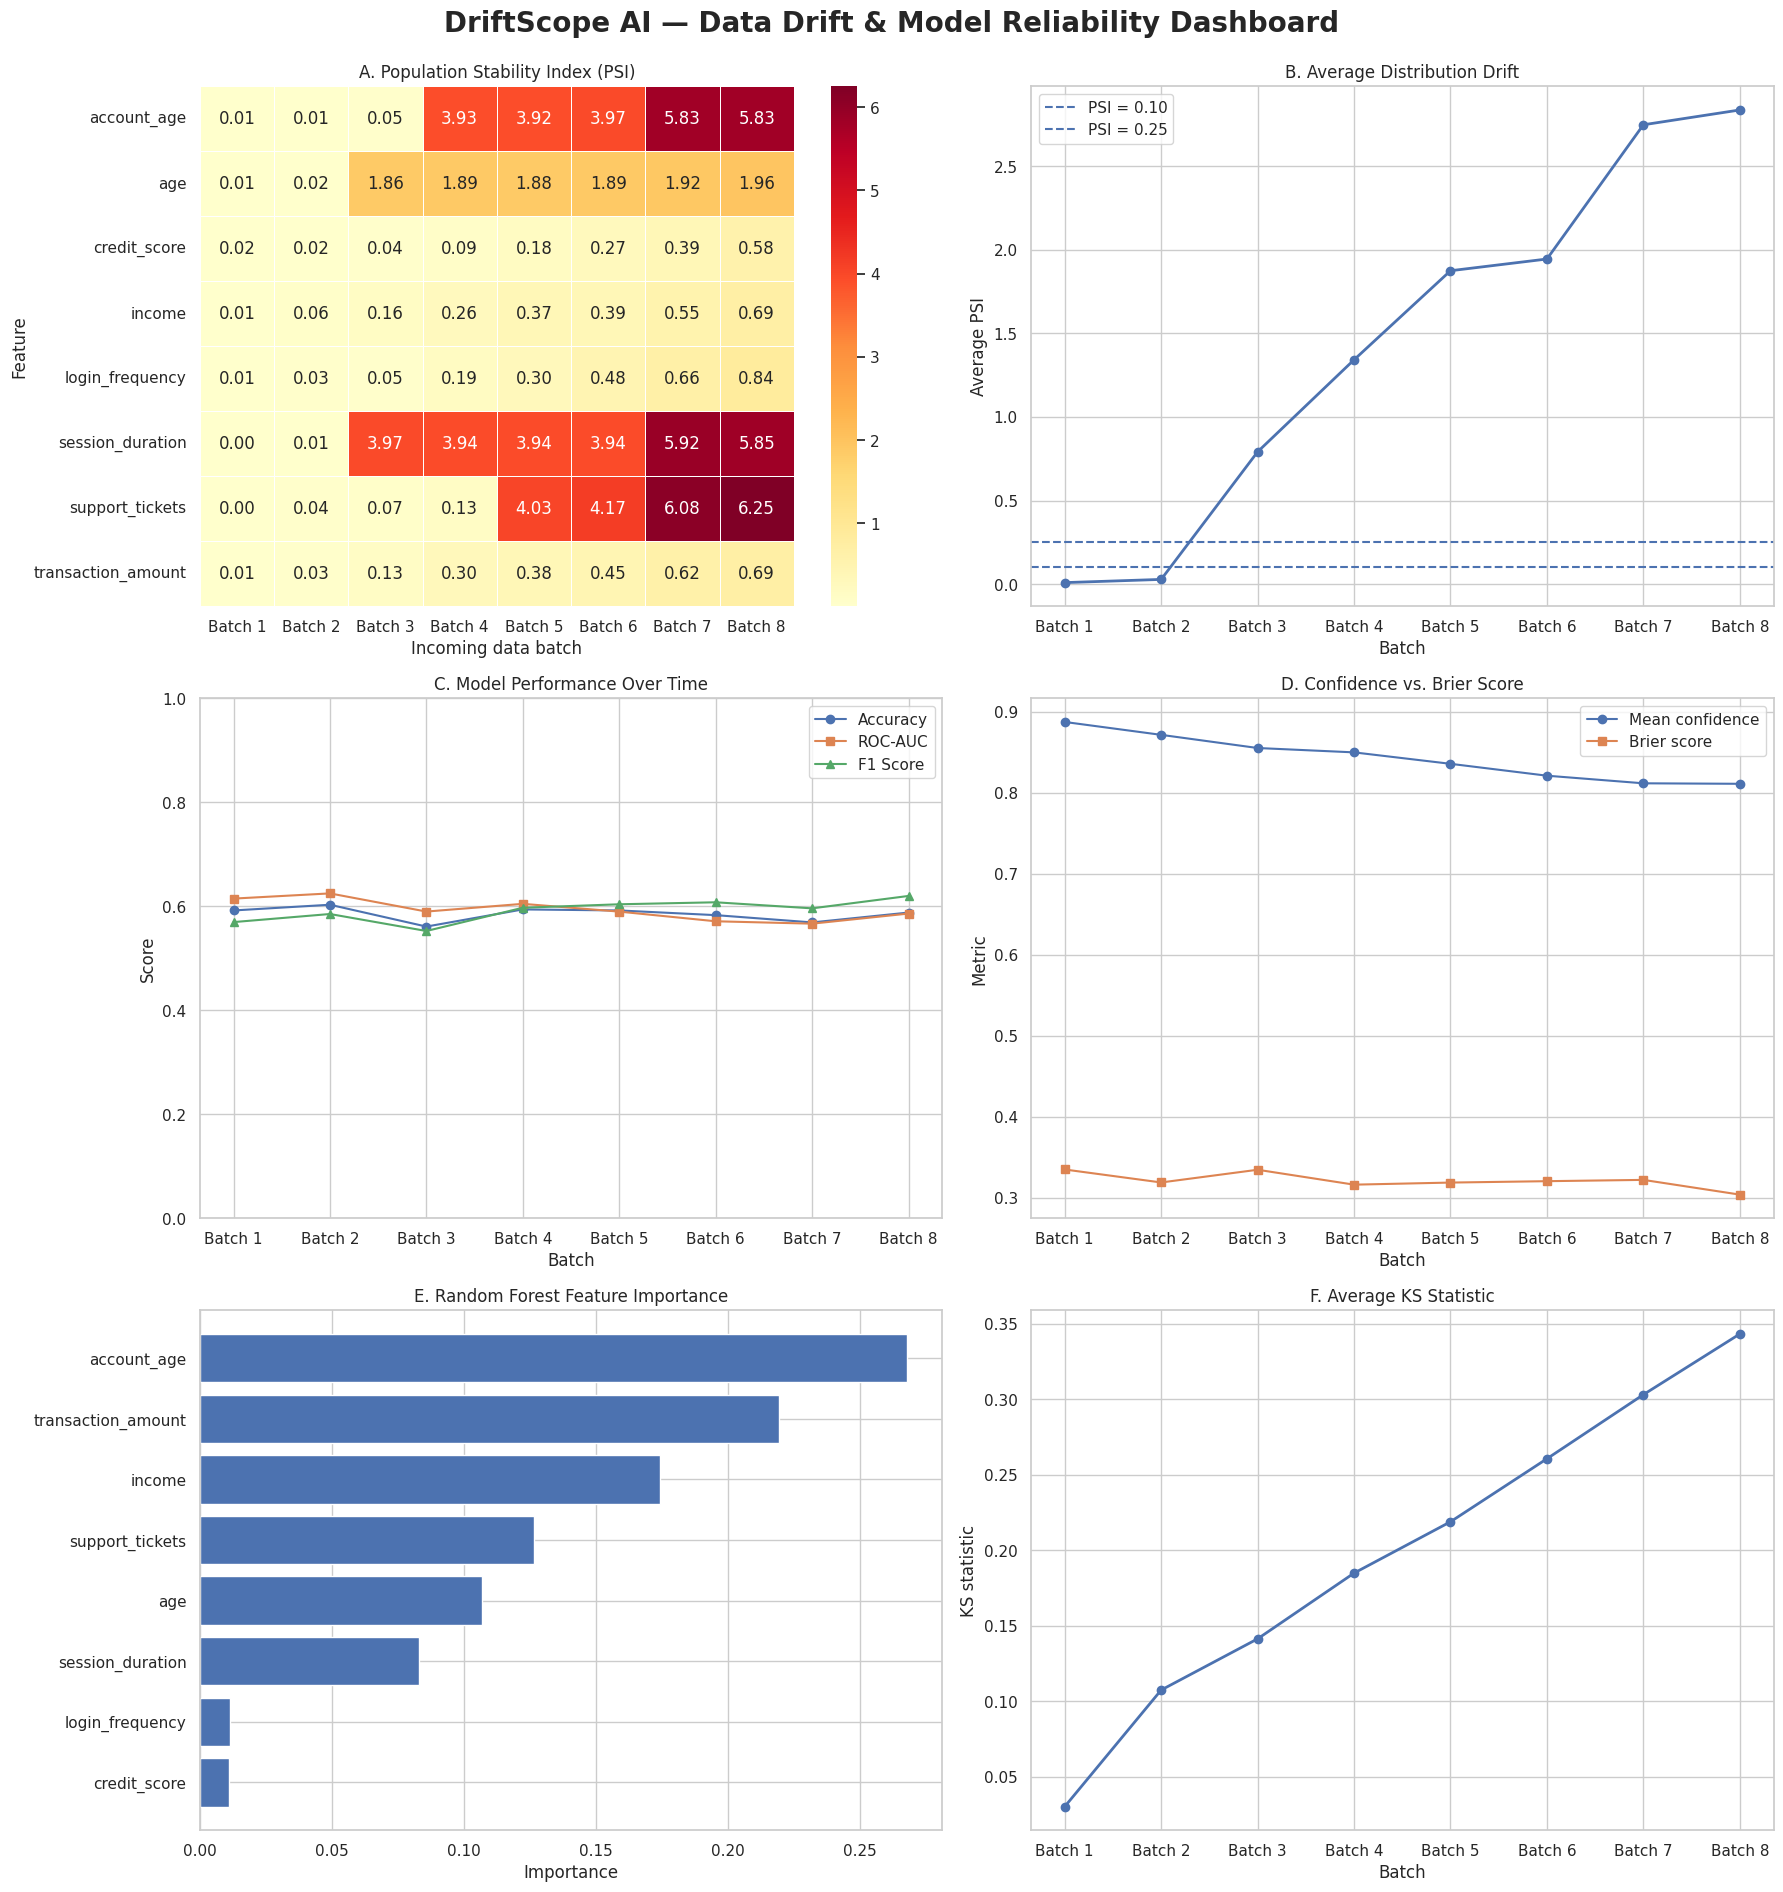

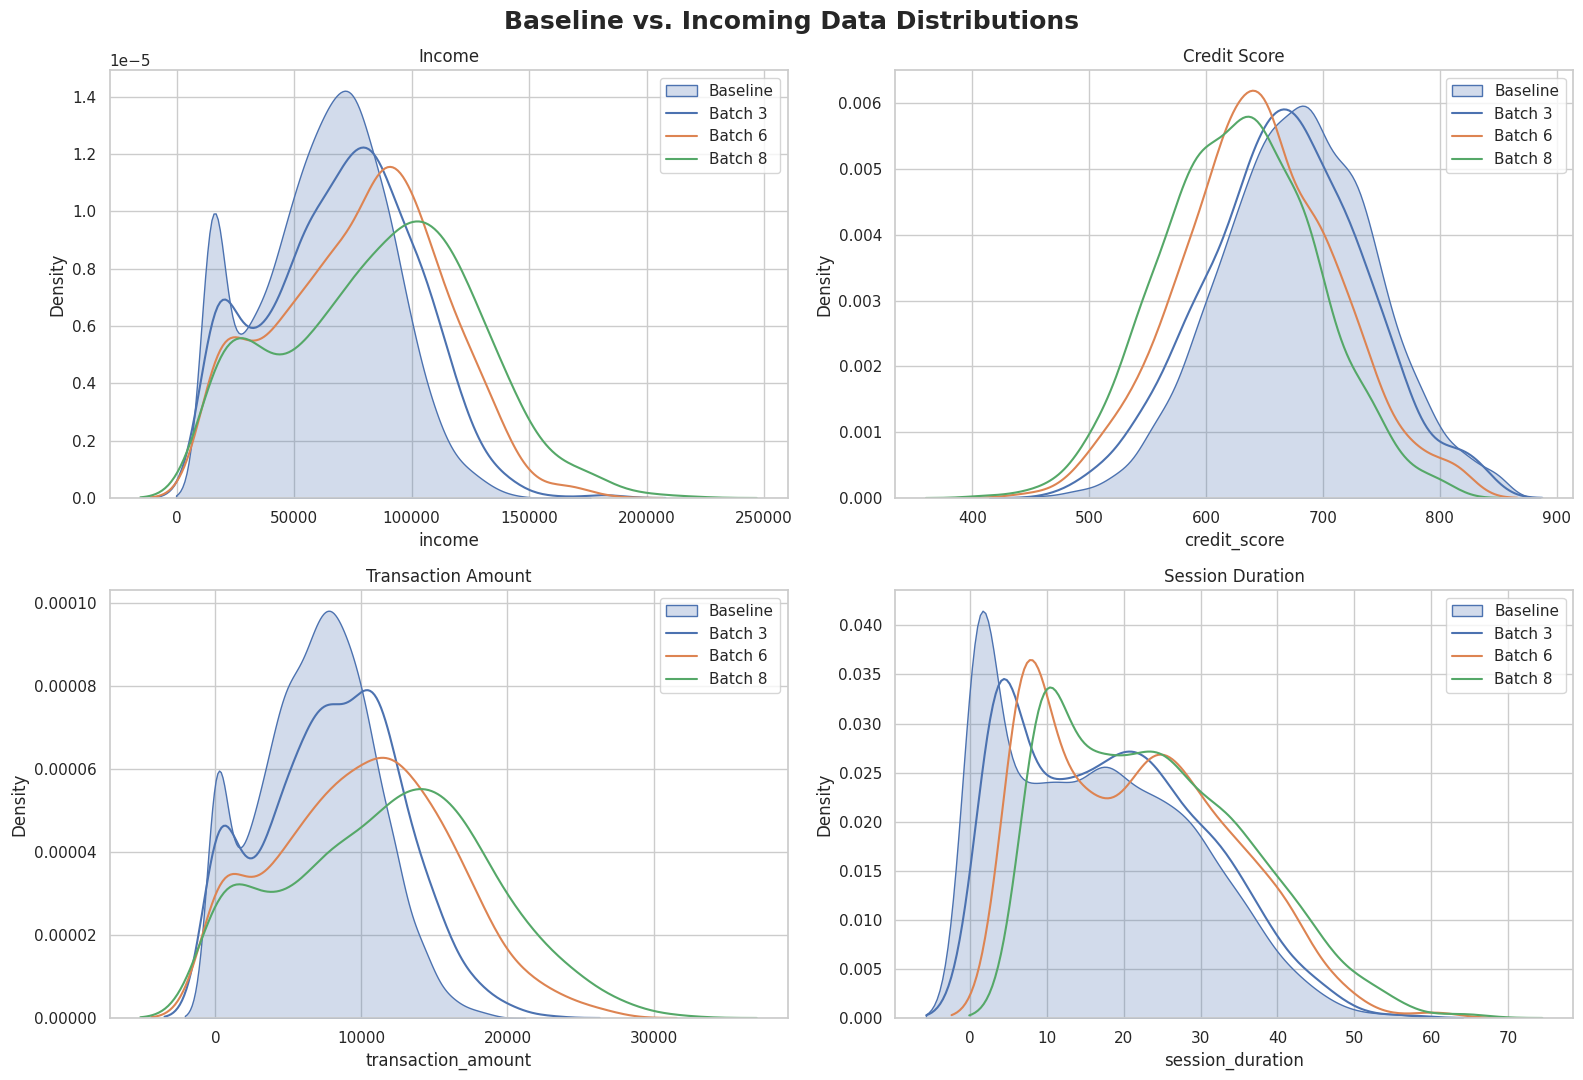

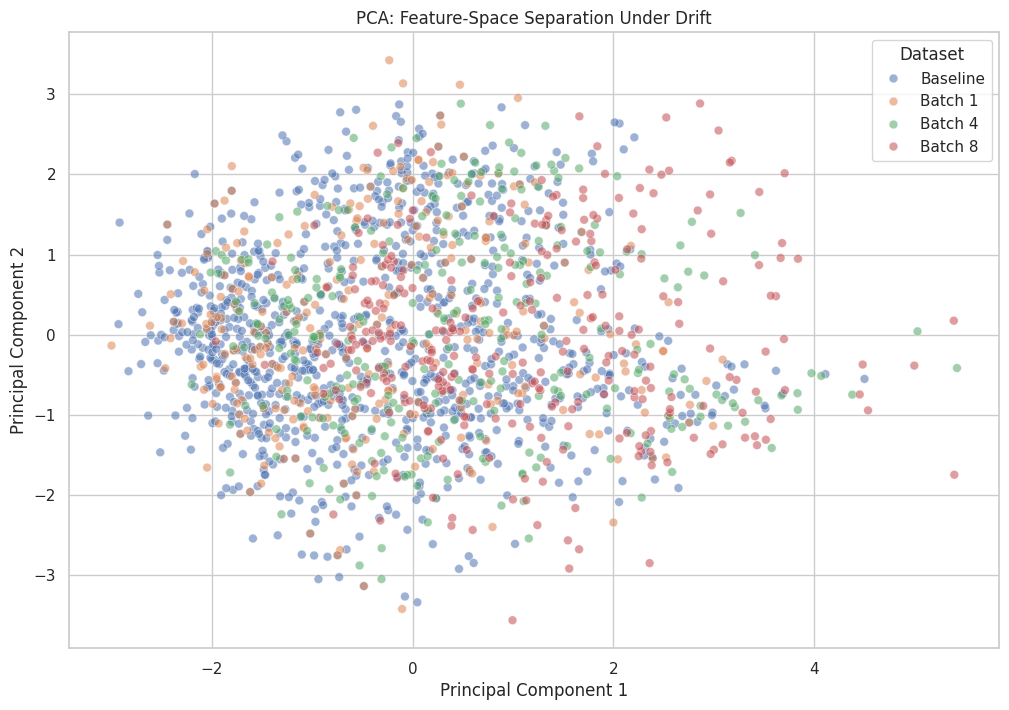

Explained variance by PC1 and PC2: [0.2684 0.1779]


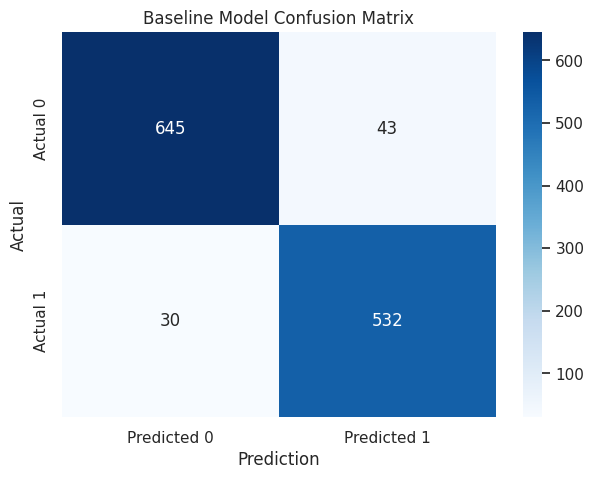


AUTOMATED DRIFT ALERT REPORT
ALERT: 8 feature(s) show potential drift.


,feature,psi,ks_stat,ks_pvalue,drift_level
62,support_tickets,6.25078,0.4036,0.0,High
63,session_duration,5.85132,0.3484,0.0,High
59,account_age,5.83311,0.3526,0.0,High
56,age,1.95787,0.1986,0.0,High
61,login_frequency,0.83953,0.3572,0.0,High
60,transaction_amount,0.69263,0.4272,0.0,High
57,income,0.68689,0.3488,0.0,High
58,credit_score,0.57675,0.3102,0.0,High



RESEARCH SUMMARY


,Research indicator,Value
0,Baseline accuracy,0.9416
1,Baseline ROC-AUC,0.9831
2,Highest average PSI feature,session_duration
3,Latest batch average PSI,2.8361
4,Lowest accuracy batch,Batch 3
5,Lowest accuracy,0.561



TOP FEATURES BY AVERAGE DRIFT


,feature,average_psi
0,session_duration,3.4469
1,account_age,2.9431
2,support_tickets,2.5981
3,age,1.4286
4,transaction_amount,0.3267
5,login_frequency,0.3202
6,income,0.3124
7,credit_score,0.1986



FILES EXPORTED:
1. driftscope_baseline_dataset.csv
2. driftscope_incoming_stream.csv
3. driftscope_drift_statistics.csv
4. driftscope_model_performance.csv
5. driftscope_feature_importance.csv

PROJECT COMPLETED SUCCESSFULLY!


In [1]:

# ============================================================
# DriftScope AI
# Machine Learning Data Drift & Reliability Observatory
# Complete research-oriented project in ONE Google Colab cell
# ============================================================

# -----------------------------
# 1. INSTALL / IMPORT LIBRARIES
# -----------------------------
import sys
import subprocess
import importlib.util

required = {
    "numpy": "numpy",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
    "scipy": "scipy",
    "sklearn": "scikit-learn"
}

for module, package in required.items():
    if importlib.util.find_spec(module) is None:
        subprocess.check_call([
            sys.executable, "-m", "pip", "install", "-q", package
        ])

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import ks_2samp, wasserstein_distance
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, log_loss,
    confusion_matrix, brier_score_loss
)
from sklearn.calibration import calibration_curve
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from IPython.display import display, Markdown

np.random.seed(42)
sns.set_theme(style="whitegrid", context="notebook")

# -----------------------------
# 2. PROJECT CONFIGURATION
# -----------------------------
N_BASELINE = 5000
N_BATCH = 1000
N_BATCHES = 8
N_FEATURES = 8

FEATURES = [
    "age",
    "income",
    "credit_score",
    "account_age",
    "transaction_amount",
    "login_frequency",
    "support_tickets",
    "session_duration"
]

print("=" * 70)
print("DRIFTSCOPE AI | DATA DRIFT & RELIABILITY OBSERVATORY")
print("=" * 70)

# -----------------------------
# 3. GENERATE BASELINE DATA
# -----------------------------
X, y = make_classification(
    n_samples=N_BASELINE,
    n_features=N_FEATURES,
    n_informative=5,
    n_redundant=1,
    n_repeated=0,
    n_classes=2,
    weights=[0.55, 0.45],
    class_sep=1.2,
    random_state=42
)

baseline = pd.DataFrame(X, columns=FEATURES)

# Transform normalized features into interpretable business-like values
baseline["age"] = np.clip(
    35 + baseline["age"] * 10, 18, 80
)
baseline["income"] = np.clip(
    50000 + baseline["income"] * 18000, 15000, 250000
)
baseline["credit_score"] = np.clip(
    680 + baseline["credit_score"] * 65, 300, 850
)
baseline["account_age"] = np.clip(
    48 + baseline["account_age"] * 20, 1, 180
)
baseline["transaction_amount"] = np.clip(
    5000 + baseline["transaction_amount"] * 2500,
    50, 50000
)
baseline["login_frequency"] = np.clip(
    10 + baseline["login_frequency"] * 5, 0, 100
)
baseline["support_tickets"] = np.clip(
    3 + baseline["support_tickets"] * 2, 0, 30
)
baseline["session_duration"] = np.clip(
    15 + baseline["session_duration"] * 8, 1, 120
)

baseline = baseline.reset_index(drop=True)
y = pd.Series(y, name="target")

# -----------------------------
# 4. TRAIN / TEST SPLIT
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    baseline, y,
    test_size=0.25,
    stratify=y,
    random_state=42
)

model = RandomForestClassifier(
    n_estimators=150,
    max_depth=10,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

baseline_pred = model.predict(X_test)
baseline_prob = model.predict_proba(X_test)[:, 1]

baseline_metrics = {
    "Accuracy": accuracy_score(y_test, baseline_pred),
    "Precision": precision_score(y_test, baseline_pred),
    "Recall": recall_score(y_test, baseline_pred),
    "F1 Score": f1_score(y_test, baseline_pred),
    "ROC-AUC": roc_auc_score(y_test, baseline_prob),
    "Log Loss": log_loss(y_test, model.predict_proba(X_test)),
    "Brier Score": brier_score_loss(y_test, baseline_prob)
}

print("\nBASELINE MODEL PERFORMANCE")
display(pd.DataFrame([baseline_metrics]).round(4))

# -----------------------------
# 5. SIMULATE DATA DRIFT
# -----------------------------
# Each batch represents a later period of incoming data.
# Drift increases gradually across the batches.

def generate_drifted_batch(reference, severity, batch_id):
    batch = reference.sample(
        n=N_BATCH,
        replace=True,
        random_state=100 + batch_id
    ).copy().reset_index(drop=True)

    # Gradual distribution changes
    batch["age"] += severity * 5
    batch["income"] *= (1 + severity * 0.25)
    batch["credit_score"] -= severity * 30
    batch["account_age"] += severity * 12
    batch["transaction_amount"] *= (1 + severity * 0.45)
    batch["login_frequency"] -= severity * 3
    batch["support_tickets"] += severity * 2
    batch["session_duration"] += severity * 5

    # Mildly increase variance in selected features
    batch["income"] += np.random.normal(
        0, severity * 6000, len(batch)
    )
    batch["transaction_amount"] += np.random.normal(
        0, severity * 800, len(batch)
    )

    # Keep values within plausible ranges
    batch["age"] = np.clip(batch["age"], 18, 80)
    batch["income"] = np.clip(batch["income"], 15000, 300000)
    batch["credit_score"] = np.clip(batch["credit_score"], 300, 850)
    batch["account_age"] = np.clip(batch["account_age"], 1, 180)
    batch["transaction_amount"] = np.clip(
        batch["transaction_amount"], 50, 100000
    )
    batch["login_frequency"] = np.clip(
        batch["login_frequency"], 0, 100
    )
    batch["support_tickets"] = np.clip(
        batch["support_tickets"], 0, 30
    )
    batch["session_duration"] = np.clip(
        batch["session_duration"], 1, 120
    )

    return batch

batches = []
severities = np.linspace(0, 1.6, N_BATCHES)

for i, severity in enumerate(severities, start=1):
    batch = generate_drifted_batch(
        baseline, severity, i
    )
    batch["batch"] = f"Batch {i}"
    batch["severity"] = severity
    batches.append(batch)

stream = pd.concat(batches, ignore_index=True)

print("\nSTREAM DATASET CREATED")
print(f"Baseline rows: {len(baseline):,}")
print(f"Incoming rows: {len(stream):,}")
print(f"Features: {len(FEATURES)}")

# -----------------------------
# 6. DRIFT METRICS
# -----------------------------
# PSI: Population Stability Index
# KS: Kolmogorov-Smirnov statistic
# Wasserstein: Distribution distance

def calculate_psi(reference, current, bins=10):
    reference = np.asarray(reference, dtype=float)
    current = np.asarray(current, dtype=float)

    edges = np.unique(
        np.quantile(reference, np.linspace(0, 1, bins + 1))
    )

    if len(edges) < 3:
        return 0.0

    ref_counts, _ = np.histogram(reference, bins=edges)
    cur_counts, _ = np.histogram(current, bins=edges)

    ref_pct = (ref_counts + 1e-6) / (len(reference) + 1e-6 * bins)
    cur_pct = (cur_counts + 1e-6) / (len(current) + 1e-6 * bins)

    return np.sum(
        (cur_pct - ref_pct) * np.log(cur_pct / ref_pct)
    )

def calculate_drift(reference, current):
    psi = calculate_psi(reference, current)
    ks_stat, ks_p = ks_2samp(reference, current)
    wasserstein = wasserstein_distance(reference, current)

    return psi, ks_stat, ks_p, wasserstein

drift_records = []

for batch_name, batch in stream.groupby("batch", sort=False):
    severity = batch["severity"].iloc[0]

    for feature in FEATURES:
        psi, ks_stat, ks_p, wasserstein = calculate_drift(
            baseline[feature],
            batch[feature]
        )

        drift_records.append({
            "batch": batch_name,
            "severity": severity,
            "feature": feature,
            "psi": psi,
            "ks_stat": ks_stat,
            "ks_pvalue": ks_p,
            "wasserstein": wasserstein
        })

drift_df = pd.DataFrame(drift_records)

# Practical PSI interpretation, used as a screening heuristic.
def psi_label(value):
    if value < 0.10:
        return "Low"
    elif value < 0.25:
        return "Moderate"
    return "High"

drift_df["drift_level"] = drift_df["psi"].apply(psi_label)

print("\nDRIFT STATISTICS")
display(drift_df.head(10).round(4))

# -----------------------------
# 7. MODEL PERFORMANCE BY BATCH
# -----------------------------
performance_records = []

for batch_name, batch in stream.groupby("batch", sort=False):
    severity = batch["severity"].iloc[0]

    # Generate labels from the original classification relationship.
    # This creates a controlled evaluation scenario.
    raw_score = (
        0.018 * (batch["credit_score"] - 680)
        - 0.000012 * (batch["income"] - 50000)
        - 0.00025 * (batch["transaction_amount"] - 5000)
        + 0.04 * batch["login_frequency"]
        - 0.08 * batch["support_tickets"]
        + 0.025 * batch["session_duration"]
        + np.random.normal(0, 1.0, len(batch))
    )

    probabilities = 1 / (1 + np.exp(-raw_score / 3))
    labels = (probabilities > np.median(probabilities)).astype(int)

    predictions = model.predict(batch[FEATURES])
    prediction_probs = model.predict_proba(batch[FEATURES])[:, 1]

    performance_records.append({
        "batch": batch_name,
        "severity": severity,
        "accuracy": accuracy_score(labels, predictions),
        "precision": precision_score(
            labels, predictions, zero_division=0
        ),
        "recall": recall_score(
            labels, predictions, zero_division=0
        ),
        "f1": f1_score(
            labels, predictions, zero_division=0
        ),
        "roc_auc": roc_auc_score(labels, prediction_probs),
        "log_loss": log_loss(
            labels, model.predict_proba(batch[FEATURES])
        ),
        "brier_score": brier_score_loss(labels, prediction_probs),
        "mean_confidence": np.mean(
            np.maximum(prediction_probs, 1 - prediction_probs)
        )
    })

performance_df = pd.DataFrame(performance_records)

print("\nMODEL PERFORMANCE ACROSS DATA BATCHES")
display(performance_df.round(4))

# -----------------------------
# 8. FEATURE IMPORTANCE
# -----------------------------
importance_df = pd.DataFrame({
    "feature": FEATURES,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=False)

# -----------------------------
# 9. VISUALIZATION DASHBOARD
# -----------------------------
fig, axes = plt.subplots(3, 2, figsize=(18, 19))
fig.suptitle(
    "DriftScope AI — Data Drift & Model Reliability Dashboard",
    fontsize=20,
    fontweight="bold",
    y=0.995
)

# A. Feature drift heatmap
heatmap_data = drift_df.pivot(
    index="feature", columns="batch", values="psi"
)

sns.heatmap(
    heatmap_data,
    cmap="YlOrRd",
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    ax=axes[0, 0]
)
axes[0, 0].set_title("A. Population Stability Index (PSI)")
axes[0, 0].set_xlabel("Incoming data batch")
axes[0, 0].set_ylabel("Feature")

# B. Overall average drift
avg_drift = drift_df.groupby("batch", sort=False)["psi"].mean()

axes[0, 1].plot(
    avg_drift.index,
    avg_drift.values,
    marker="o",
    linewidth=2
)
axes[0, 1].axhline(
    0.10, linestyle="--",
    label="PSI = 0.10"
)
axes[0, 1].axhline(
    0.25, linestyle="--",
    label="PSI = 0.25"
)
axes[0, 1].set_title("B. Average Distribution Drift")
axes[0, 1].set_xlabel("Batch")
axes[0, 1].set_ylabel("Average PSI")
axes[0, 1].legend()

# C. Model performance
axes[1, 0].plot(
    performance_df["batch"],
    performance_df["accuracy"],
    marker="o",
    label="Accuracy"
)
axes[1, 0].plot(
    performance_df["batch"],
    performance_df["roc_auc"],
    marker="s",
    label="ROC-AUC"
)
axes[1, 0].plot(
    performance_df["batch"],
    performance_df["f1"],
    marker="^",
    label="F1 Score"
)
axes[1, 0].set_title("C. Model Performance Over Time")
axes[1, 0].set_xlabel("Batch")
axes[1, 0].set_ylabel("Score")
axes[1, 0].set_ylim(0, 1)
axes[1, 0].legend()

# D. Confidence and calibration-related metric
axes[1, 1].plot(
    performance_df["batch"],
    performance_df["mean_confidence"],
    marker="o",
    label="Mean confidence"
)
axes[1, 1].plot(
    performance_df["batch"],
    performance_df["brier_score"],
    marker="s",
    label="Brier score"
)
axes[1, 1].set_title("D. Confidence vs. Brier Score")
axes[1, 1].set_xlabel("Batch")
axes[1, 1].set_ylabel("Metric")
axes[1, 1].legend()

# E. Feature importance
top_features = importance_df.head(8).sort_values("importance")

axes[2, 0].barh(
    top_features["feature"],
    top_features["importance"]
)
axes[2, 0].set_title("E. Random Forest Feature Importance")
axes[2, 0].set_xlabel("Importance")

# F. KS statistic trend
ks_avg = drift_df.groupby("batch", sort=False)["ks_stat"].mean()

axes[2, 1].plot(
    ks_avg.index,
    ks_avg.values,
    marker="o",
    linewidth=2
)
axes[2, 1].set_title("F. Average KS Statistic")
axes[2, 1].set_xlabel("Batch")
axes[2, 1].set_ylabel("KS statistic")

plt.tight_layout()
plt.show()

# -----------------------------
# 10. DETAILED FEATURE DISTRIBUTIONS
# -----------------------------
selected_features = [
    "income",
    "credit_score",
    "transaction_amount",
    "session_duration"
]

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle(
    "Baseline vs. Incoming Data Distributions",
    fontsize=18,
    fontweight="bold"
)

for ax, feature in zip(axes.ravel(), selected_features):
    sns.kdeplot(
        baseline[feature],
        ax=ax,
        label="Baseline",
        fill=True,
        alpha=0.25
    )

    for batch_name in ["Batch 3", "Batch 6", "Batch 8"]:
        sns.kdeplot(
            stream.loc[
                stream["batch"] == batch_name, feature
            ],
            ax=ax,
            label=batch_name
        )

    ax.set_title(feature.replace("_", " ").title())
    ax.legend()

plt.tight_layout()
plt.show()

# -----------------------------
# 11. PCA VISUALIZATION
# -----------------------------
scaler = StandardScaler()

combined_sample = pd.concat([
    baseline.sample(1000, random_state=42)[FEATURES],
    stream.loc[
        stream["batch"].isin(["Batch 1", "Batch 4", "Batch 8"]),
        FEATURES
    ].groupby(stream["batch"]).head(300)
], ignore_index=True)

scaled = scaler.fit_transform(combined_sample)
pca = PCA(n_components=2)
components = pca.fit_transform(scaled)

pca_df = pd.DataFrame({
    "PC1": components[:, 0],
    "PC2": components[:, 1],
    "group": (
        ["Baseline"] * 1000
        + ["Batch 1"] * 300
        + ["Batch 4"] * 300
        + ["Batch 8"] * 300
    )
})

plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="group",
    alpha=0.55,
    s=40
)
plt.title("PCA: Feature-Space Separation Under Drift")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Dataset")
plt.show()

print(
    "Explained variance by PC1 and PC2:",
    np.round(pca.explained_variance_ratio_, 4)
)

# -----------------------------
# 12. CONFUSION MATRIX
# -----------------------------
cm = confusion_matrix(y_test, baseline_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Predicted 0", "Predicted 1"],
    yticklabels=["Actual 0", "Actual 1"]
)
plt.title("Baseline Model Confusion Matrix")
plt.xlabel("Prediction")
plt.ylabel("Actual")
plt.show()

# -----------------------------
# 13. AUTOMATED DRIFT ALERTS
# -----------------------------
latest_batch = drift_df["batch"].iloc[-1]
latest = drift_df[drift_df["batch"] == latest_batch]

alerts = latest[
    (latest["psi"] >= 0.25) |
    (latest["ks_pvalue"] < 0.05)
].copy()

print("\n" + "=" * 70)
print("AUTOMATED DRIFT ALERT REPORT")
print("=" * 70)

if len(alerts) > 0:
    print(f"ALERT: {len(alerts)} feature(s) show potential drift.")
    display(
        alerts[
            ["feature", "psi", "ks_stat", "ks_pvalue", "drift_level"]
        ].sort_values("psi", ascending=False).round(5)
    )
else:
    print("No high-drift features detected in the latest batch.")

# -----------------------------
# 14. RESEARCH SUMMARY
# -----------------------------
most_drifted = (
    drift_df.groupby("feature")["psi"]
    .mean()
    .sort_values(ascending=False)
)

highest_batch = performance_df.loc[
    performance_df["accuracy"].idxmin()
]

summary = pd.DataFrame({
    "Research indicator": [
        "Baseline accuracy",
        "Baseline ROC-AUC",
        "Highest average PSI feature",
        "Latest batch average PSI",
        "Lowest accuracy batch",
        "Lowest accuracy"
    ],
    "Value": [
        round(baseline_metrics["Accuracy"], 4),
        round(baseline_metrics["ROC-AUC"], 4),
        most_drifted.index[0],
        round(avg_drift.iloc[-1], 4),
        highest_batch["batch"],
        round(highest_batch["accuracy"], 4)
    ]
})

print("\nRESEARCH SUMMARY")
display(summary)

print("\nTOP FEATURES BY AVERAGE DRIFT")
display(
    most_drifted.reset_index(
        name="average_psi"
    ).round(4)
)

# -----------------------------
# 15. EXPORT RESULTS
# -----------------------------
baseline.to_csv("driftscope_baseline_dataset.csv", index=False)
stream.to_csv("driftscope_incoming_stream.csv", index=False)
drift_df.to_csv("driftscope_drift_statistics.csv", index=False)
performance_df.to_csv("driftscope_model_performance.csv", index=False)
importance_df.to_csv("driftscope_feature_importance.csv", index=False)

print("\nFILES EXPORTED:")
print("1. driftscope_baseline_dataset.csv")
print("2. driftscope_incoming_stream.csv")
print("3. driftscope_drift_statistics.csv")
print("4. driftscope_model_performance.csv")
print("5. driftscope_feature_importance.csv")

print("\nPROJECT COMPLETED SUCCESSFULLY!")